# LAB 4: BÀI THỰC HÀNH CHUẨN BỊ DỮ LIỆU

## Thư viện & Upload dữ liệu

In [ ]:
# Upload file titanic_disaster.csv lên Colab
from google.colab import files
uploaded = files.upload()

Saving titanic_disaster.csv to titanic_disaster (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

---
# PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING

## 1 – Load dữ liệu

In [ ]:
def load_data(filepath='titanic_disaster.csv'):
    df = pd.read_csv(filepath)
    print(f'Shape: {df.shape}  ({df.shape[0]} hàng x {df.shape[1]} cột)')
    print('\n=== 10 DÒNG ĐẦU TIÊN ===')
    display(df.head(10))
    print('\n=== THÔNG TIN CỘT ===')
    df.info()
    return df

df = load_data()

Shape: (891, 12)  (891 hàng x 12 cột)

=== 10 DÒNG ĐẦU TIÊN ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C



=== THÔNG TIN CỘT ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 2 – Thống kê dữ liệu thiếu & Heatmap

In [ ]:
# Bảng thống kê dữ liệu thiếu
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Tỉ lệ thiếu (%)': missing_pct
})
print('=== THỐNG KÊ DỮ LIỆU THIẾU ===')
display(missing_table[missing_table['Số lượng thiếu'] > 0])

=== THỐNG KÊ DỮ LIỆU THIẾU ===


,Số lượng thiếu,Tỉ lệ thiếu (%)
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


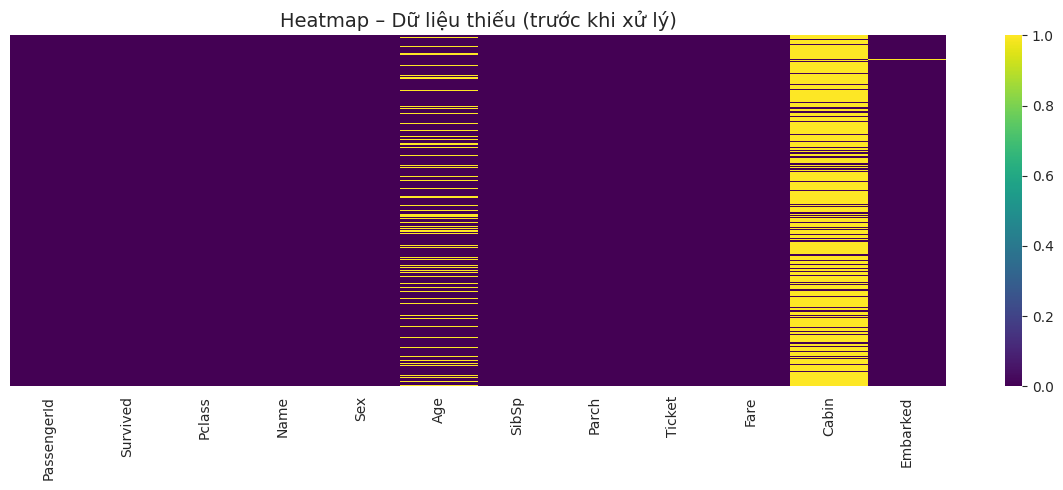

In [ ]:
# Heatmap trực quan dữ liệu thiếu
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Heatmap – Dữ liệu thiếu (trước khi xử lý)', fontsize=14)
plt.tight_layout()
plt.show()

**Nhận xét:**
- **Age**: thiếu 177 giá trị (~19.9%) → thay thế bằng **mean tuổi theo từng nhóm Pclass**
- **Cabin**: thiếu 687 giá trị (~77.1%) → quá nhiều, thay bằng `'Unknown'` rồi lấy ký tự đầu làm `typeCabin`
- **Embarked**: thiếu 2 giá trị (~0.2%) → điền bằng **mode** (giá trị phổ biến nhất)

## 3 – Tách cột Name → firstName, secondName

In [ ]:
# Name có dạng: "Braund, Mr. Owen Harris"
# Trước dấu phẩy = secondName (họ), sau dấu phẩy = firstName (tên + danh xưng)
df[['secondName', 'firstName']] = df['Name'].str.split(',', n=1, expand=True)
df['secondName'] = df['secondName'].str.strip()
df['firstName']  = df['firstName'].str.strip()
df.drop(columns=['Name'], inplace=True)

print('=== KẾT QUẢ TÁCH TÊN (5 dòng đầu) ===')
display(df[['secondName', 'firstName']].head())

=== KẾT QUẢ TÁCH TÊN (5 dòng đầu) ===


,secondName,firstName
0,Braund,Mr. Owen Harris
1,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,Heikkinen,Miss. Laina
3,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,Allen,Mr. William Henry


## 4 – Rút gọn cột Sex: male → M, female → F

In [ ]:
df['Sex'] = df['Sex'].map({'male': 'M', 'female': 'F'})

print('=== GIÁ TRỊ SEX SAU RÚT GỌN ===')
print(df['Sex'].value_counts())

=== GIÁ TRỊ SEX SAU RÚT GỌN ===
Sex
M    577
F    314
Name: count, dtype: int64


## 5a – Boxplot tuổi theo Pclass → quyết định cách thay thế Age

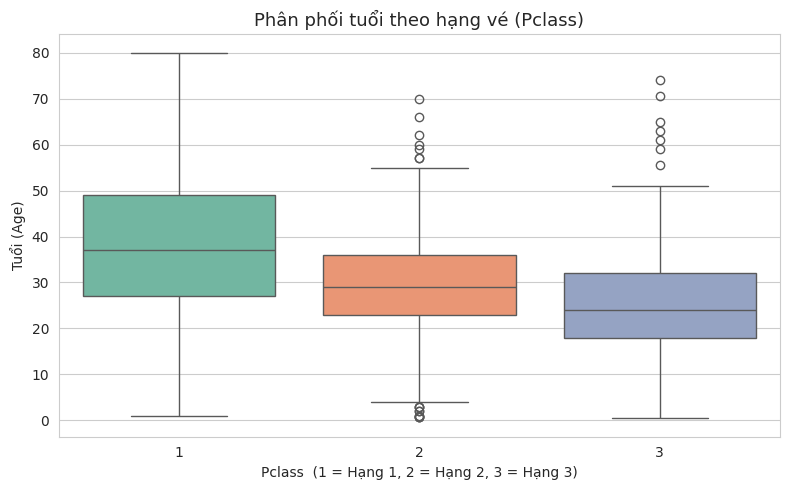


=== TUỔI TRUNG BÌNH THEO PCLASS ===
Pclass
1    38.2
2    29.9
3    25.1
Name: Age, dtype: float64


In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')
plt.title('Phân phối tuổi theo hạng vé (Pclass)', fontsize=13)
plt.xlabel('Pclass  (1 = Hạng 1, 2 = Hạng 2, 3 = Hạng 3)')
plt.ylabel('Tuổi (Age)')
plt.tight_layout()
plt.show()

print('\n=== TUỔI TRUNG BÌNH THEO PCLASS ===')
print(df.groupby('Pclass')['Age'].mean().round(1))

**Nhận xét:** Tuổi trung bình khác nhau rõ rệt giữa 3 hạng vé:

- Hạng 1 (Xấp xỉ 38 Tuổi) > Hạng 2 (Xấp xỉ 30 Tuổi) > Hạng 3 (Xấp xỉ 25 Tuổi)

→ **Quyết định:** Thay thế `Age` thiếu bằng **mean của từng nhóm Pclass** (không dùng mean toàn bộ vì sẽ làm lệch phân phối)

## 5b – Thay thế Age thiếu theo Pclass

Số giá trị Age còn thiếu sau xử lý: 0


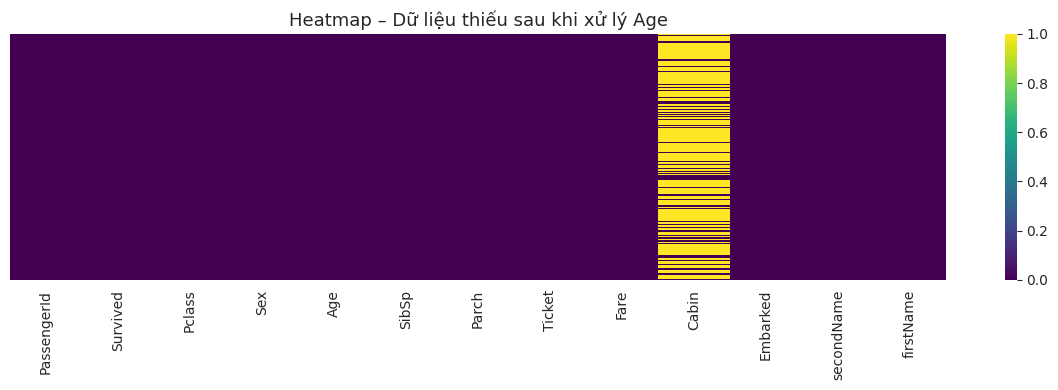

In [ ]:
for pclass in [1, 2, 3]:
    mean_age = df.loc[df['Pclass'] == pclass, 'Age'].mean()
    df.loc[(df['Age'].isnull()) & (df['Pclass'] == pclass), 'Age'] = round(mean_age, 1)

print(f'Số giá trị Age còn thiếu sau xử lý: {df["Age"].isnull().sum()}')

# Heatmap sau khi xử lý Age
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Heatmap – Dữ liệu thiếu sau khi xử lý Age', fontsize=13)
plt.tight_layout()
plt.show()

## 6 – Tạo biến AgeGroup

In [ ]:
# (0, 12] → Kid | (12, 18] → Teen | (18, 60] → Adult | (60, ∞) → Older
bins   = [0, 12, 18, 60, 200]
labels = ['Kid', 'Teen', 'Adult', 'Older']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

print('=== PHÂN BỐ AgeGroup ===')
display(df['AgeGroup'].value_counts().sort_index().to_frame())

=== PHÂN BỐ AgeGroup ===


,count
AgeGroup,
Kid,69
Teen,70
Adult,730
Older,22


## 7 – Tách danh xưng (namePrefix) từ firstName

In [ ]:
# firstName dạng: "Mr. Owen Harris" → lấy phần trước dấu chấm đầu tiên
df['namePrefix'] = df['firstName'].str.extract(r'([A-Za-z]+)\.')

# Gộp prefix hiếm gặp thành 'Other'
common = ['Mr', 'Miss', 'Mrs', 'Master']
df['namePrefix'] = df['namePrefix'].apply(lambda x: x if x in common else 'Other')

print('=== PHÂN BỐ namePrefix ===')
display(df['namePrefix'].value_counts().to_frame())

=== PHÂN BỐ namePrefix ===


,count
namePrefix,
Mr,517
Miss,182
Mrs,125
Master,40
Other,27


## 8 – Tạo biến familySize

In [ ]:
# familySize = 1 (bản thân) + SibSp (anh em/vợ chồng) + Parch (bố mẹ/con cái)
df['familySize'] = 1 + df['SibSp'] + df['Parch']

print('=== PHÂN BỐ familySize ===')
display(df['familySize'].value_counts().sort_index().to_frame())

=== PHÂN BỐ familySize ===


,count
familySize,
1,537
2,161
3,102
4,29
5,15
6,22
7,12
8,6
11,7


## 9 – Tạo biến Alone

In [ ]:
# Alone = 1 nếu đi một mình (familySize == 1), ngược lại = 0
df['Alone'] = (df['familySize'] == 1).astype(int)

print('=== PHÂN BỐ Alone ===')
print(df['Alone'].value_counts().rename({0: 'Đi nhóm (0)', 1: 'Đi một mình (1)'}))

=== PHÂN BỐ Alone ===
Alone
Đi một mình (1)    537
Đi nhóm (0)        354
Name: count, dtype: int64


## 10 – Tách typeCabin từ cột Cabin

In [ ]:
# Cabin thiếu → 'Unknown'; có giá trị → lấy ký tự đầu tiên (A, B, C, ...)
df['typeCabin'] = df['Cabin'].fillna('Unknown')
df['typeCabin'] = df['typeCabin'].apply(lambda x: x[0] if x != 'Unknown' else 'Unknown')

print('=== PHÂN BỐ typeCabin ===')
display(df['typeCabin'].value_counts().to_frame())

=== PHÂN BỐ typeCabin ===


,count
typeCabin,
Unknown,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


---
# PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA

## 12 – Tỉ lệ sống sót theo giới tính

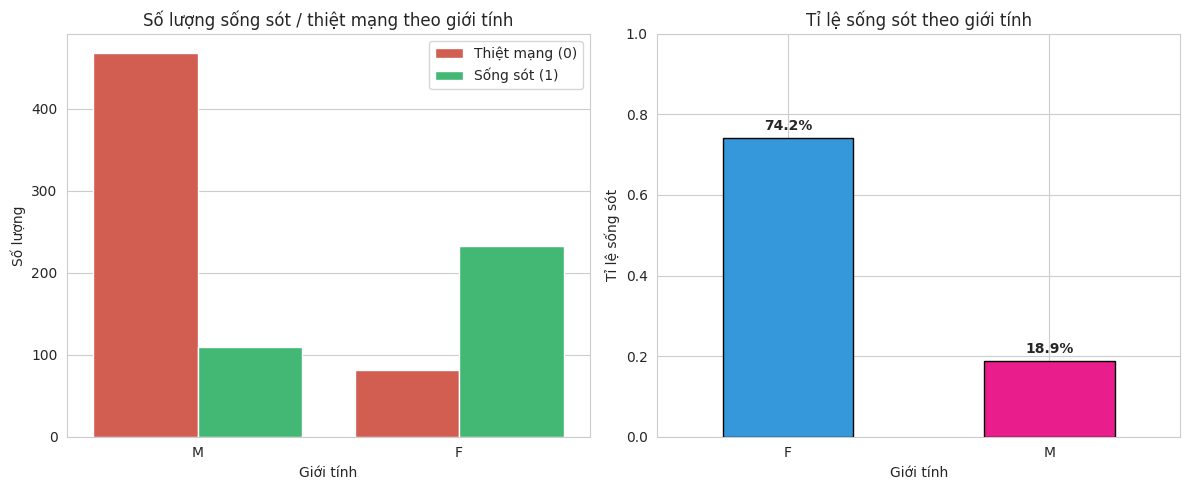

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ đếm
sns.countplot(x='Sex', hue='Survived', data=df, palette=['#e74c3c','#2ecc71'], ax=axes[0])
axes[0].set_title('Số lượng sống sót / thiệt mạng theo giới tính')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Số lượng')
axes[0].legend(['Thiệt mạng (0)', 'Sống sót (1)'])

# Biểu đồ tỉ lệ
survival_sex = df.groupby('Sex')['Survived'].mean()
survival_sex.plot(kind='bar', color=['#3498db','#e91e8c'], edgecolor='black', ax=axes[1])
axes[1].set_title('Tỉ lệ sống sót theo giới tính')
axes[1].set_xlabel('Giới tính')
axes[1].set_ylabel('Tỉ lệ sống sót')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(survival_sex):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

NHẬN XÉT:
  - Nữ (F): tỉ lệ sống sót ~74% → ưu tiên lên xuồng cứu sinh
  - Nam (M): tỉ lệ sống sót chỉ ~19%
  
  → Giới tính là đặc trưng quan trọng nhất trong bài toán dự đoán sống sót

## 13 – Sống sót theo hạng vé (Pclass)

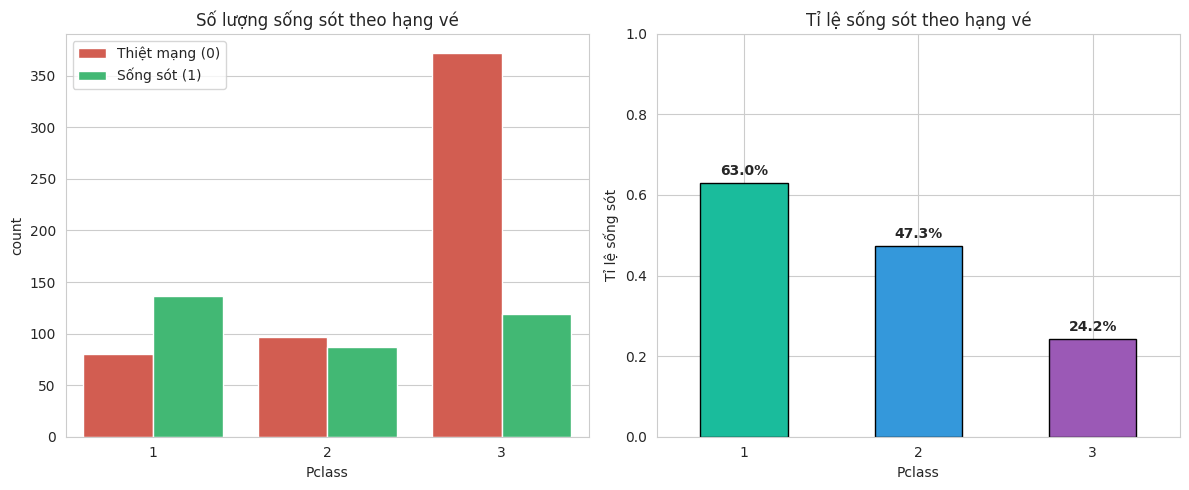

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Pclass', hue='Survived', data=df, palette=['#e74c3c','#2ecc71'], ax=axes[0])
axes[0].set_title('Số lượng sống sót theo hạng vé')
axes[0].set_xlabel('Pclass')
axes[0].legend(['Thiệt mạng (0)', 'Sống sót (1)'])

survival_pclass = df.groupby('Pclass')['Survived'].mean()
survival_pclass.plot(kind='bar', color=['#1abc9c','#3498db','#9b59b6'],
                     edgecolor='black', ax=axes[1])
axes[1].set_title('Tỉ lệ sống sót theo hạng vé')
axes[1].set_xlabel('Pclass')
axes[1].set_ylabel('Tỉ lệ sống sót')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(survival_pclass):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

NHẬN XÉT:
  - Hạng 1: tỉ lệ sống sót ~63%  → cabin gần xuồng cứu sinh, ưu tiên sơ tán
  - Hạng 2: tỉ lệ sống sót ~47%
  - Hạng 3: tỉ lệ sống sót ~24%  → cabin ở tầng dưới, khó tiếp cận xuồng

## 14 – Sống sót theo giới tính và nhóm tuổi

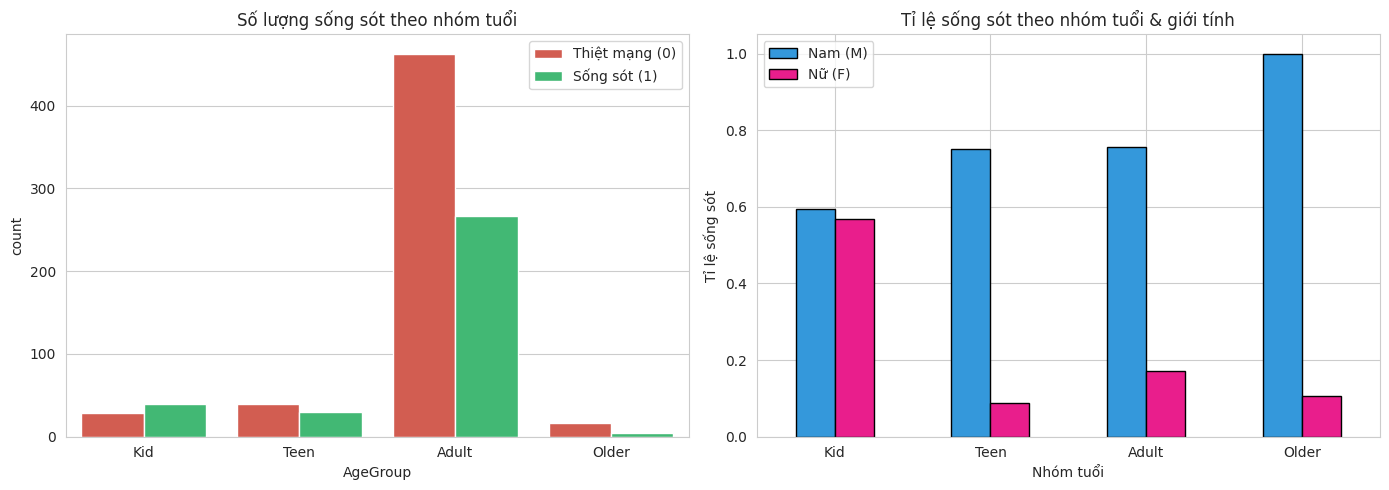

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Số lượng
sns.countplot(x='AgeGroup', hue='Survived', data=df,
              order=['Kid','Teen','Adult','Older'],
              palette=['#e74c3c','#2ecc71'], ax=axes[0])
axes[0].set_title('Số lượng sống sót theo nhóm tuổi')
axes[0].legend(['Thiệt mạng (0)', 'Sống sót (1)'])

# Tỉ lệ phân theo giới tính
survival_sex_age = df.groupby(['AgeGroup','Sex'])['Survived'].mean().unstack()
survival_sex_age.reindex(['Kid','Teen','Adult','Older']).plot(
    kind='bar', color=['#3498db','#e91e8c'], edgecolor='black', ax=axes[1])
axes[1].set_title('Tỉ lệ sống sót theo nhóm tuổi & giới tính')
axes[1].set_xlabel('Nhóm tuổi')
axes[1].set_ylabel('Tỉ lệ sống sót')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Nam (M)', 'Nữ (F)'])

plt.tight_layout()
plt.show()

NHẬN XÉT:
  - Trẻ em (Kid): tỉ lệ sống sót cao ở cả hai giới → được ưu tiên cứu trước
  - Phụ nữ (F) ở mọi nhóm tuổi đều có tỉ lệ sống sót cao hơn nam
  - Nam trưởng thành (Adult M): tỉ lệ thấp nhất

## 15 – Xác suất sống sót theo quy mô nhóm đi cùng

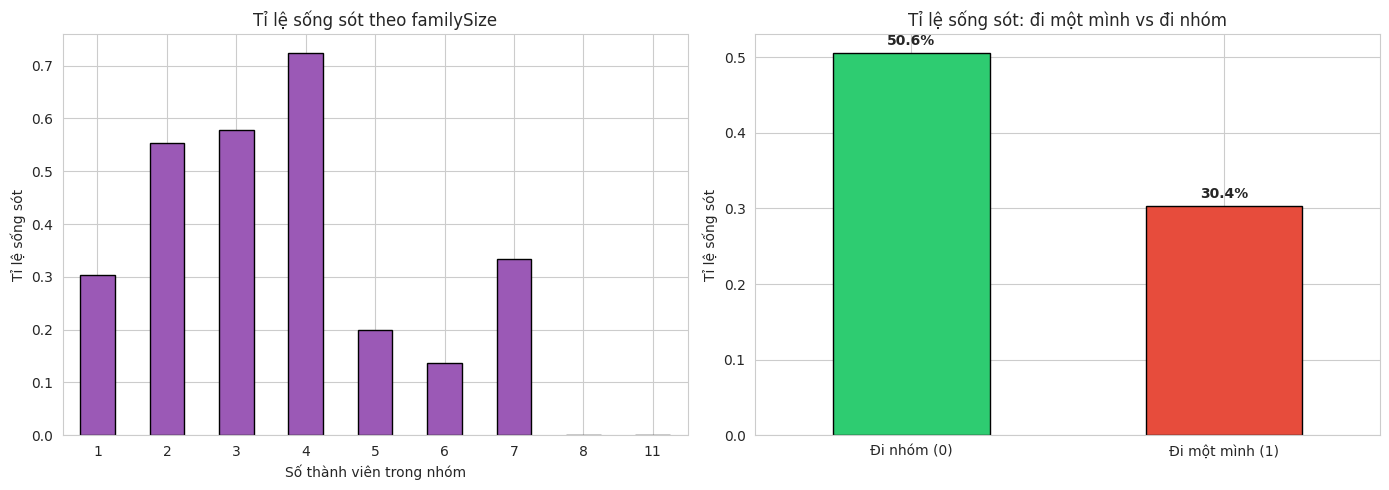

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tỉ lệ sống sót theo familySize
survival_family = df.groupby('familySize')['Survived'].mean()
survival_family.plot(kind='bar', color='#9b59b6', edgecolor='black', ax=axes[0])
axes[0].set_title('Tỉ lệ sống sót theo familySize')
axes[0].set_xlabel('Số thành viên trong nhóm')
axes[0].set_ylabel('Tỉ lệ sống sót')
axes[0].tick_params(axis='x', rotation=0)

# Tỉ lệ sống sót: đi một mình vs đi nhóm
survival_alone = df.groupby('Alone')['Survived'].mean()
survival_alone.index = ['Đi nhóm (0)', 'Đi một mình (1)']
survival_alone.plot(kind='bar', color=['#2ecc71','#e74c3c'], edgecolor='black', ax=axes[1])
axes[1].set_title('Tỉ lệ sống sót: đi một mình vs đi nhóm')
axes[1].set_ylabel('Tỉ lệ sống sót')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(survival_alone):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

NHẬN XÉT:
  - Đi một mình (Alone=1): tỉ lệ sống sót thấp hơn (~30%)
  - Nhóm 2-4 người: tỉ lệ cao nhất (~50-60%)
  - Nhóm quá lớn (≥5 người): tỉ lệ giảm mạnh (khó thoát)

## 16 – Xác suất sống sót theo giá vé (Fare)

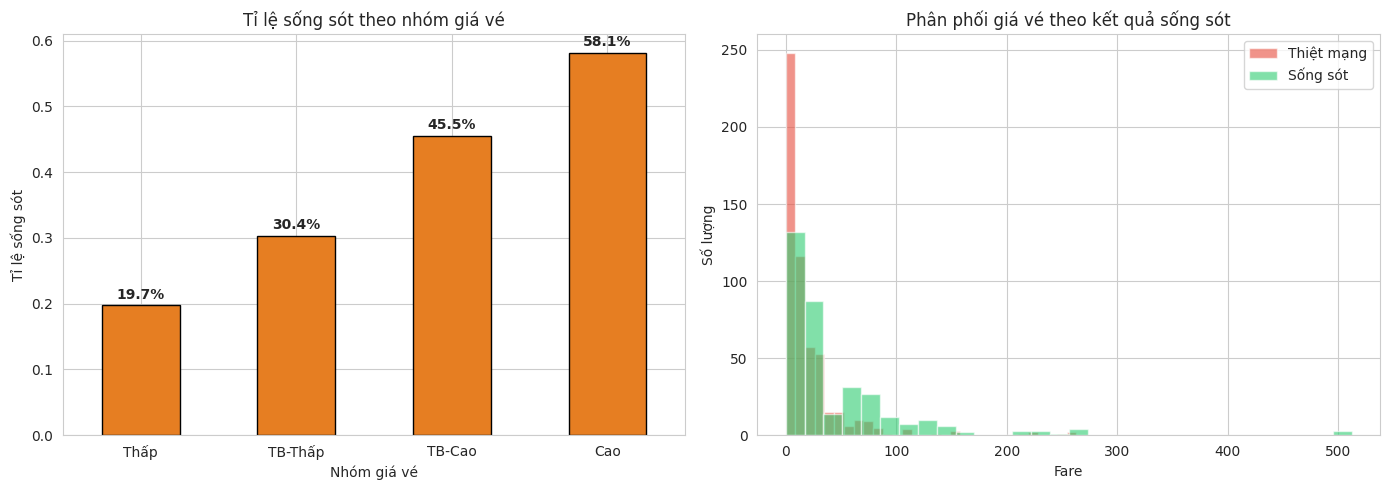

In [ ]:
# Chia Fare thành 4 nhóm bằng nhau (tứ phân vị)
df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=['Thấp','TB-Thấp','TB-Cao','Cao'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

survival_fare = df.groupby('FareBand')['Survived'].mean()
survival_fare.plot(kind='bar', color='#e67e22', edgecolor='black', ax=axes[0])
axes[0].set_title('Tỉ lệ sống sót theo nhóm giá vé')
axes[0].set_xlabel('Nhóm giá vé')
axes[0].set_ylabel('Tỉ lệ sống sót')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(survival_fare):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# Phân phối Fare theo Survived
df[df['Survived']==0]['Fare'].plot(kind='hist', bins=30, alpha=0.6,
                                    color='#e74c3c', label='Thiệt mạng', ax=axes[1])
df[df['Survived']==1]['Fare'].plot(kind='hist', bins=30, alpha=0.6,
                                    color='#2ecc71', label='Sống sót', ax=axes[1])
axes[1].set_title('Phân phối giá vé theo kết quả sống sót')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Số lượng')
axes[1].legend()

plt.tight_layout()
plt.show()

NHẬN XÉT:
  - Giá vé cao → tỉ lệ sống sót cao (~66%): vé đắt = hạng cao = cabin gần xuồng
  - Giá vé thấp → tỉ lệ sống sót thấp (~18%)
  → Fare có tương quan mạnh với Pclass và khả năng sống sót

## 17 – Số lượng thiệt mạng / sống sót theo Pclass & cảng khởi hành

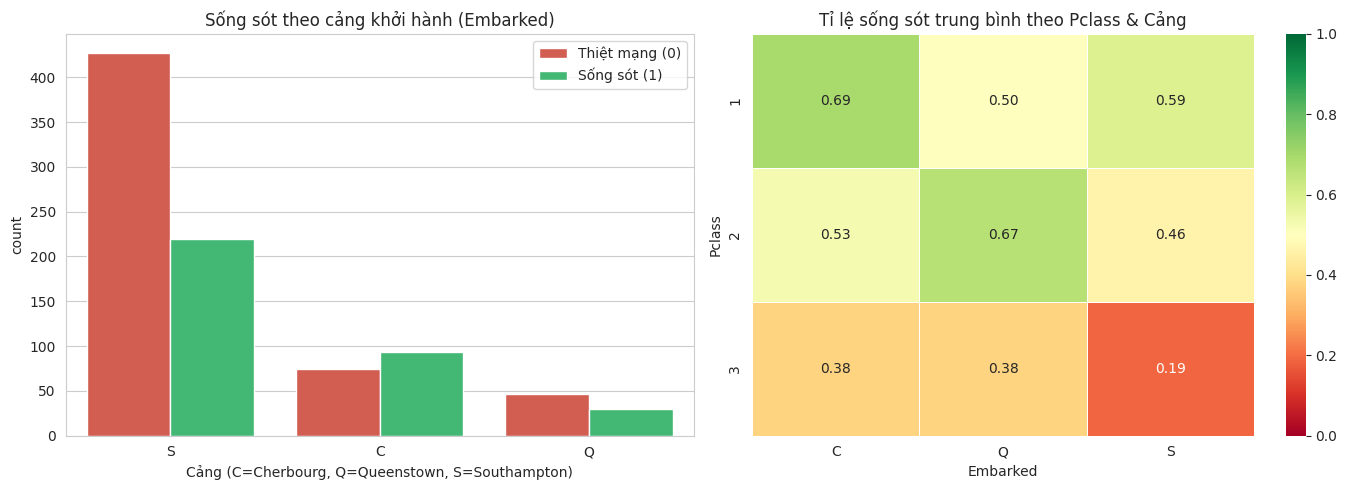

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot Pclass + Embarked
sns.countplot(x='Embarked', hue='Survived', data=df,
              palette=['#e74c3c','#2ecc71'], ax=axes[0])
axes[0].set_title('Sống sót theo cảng khởi hành (Embarked)')
axes[0].set_xlabel('Cảng (C=Cherbourg, Q=Queenstown, S=Southampton)')
axes[0].legend(['Thiệt mạng (0)', 'Sống sót (1)'])

# Heatmap crosstab Pclass x Embarked x Survived
ct = df.groupby(['Pclass','Embarked'])['Survived'].mean().unstack()
sns.heatmap(ct, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Tỉ lệ sống sót trung bình theo Pclass & Cảng')
axes[1].set_ylabel('Pclass')
axes[1].set_xlabel('Embarked')

plt.tight_layout()
plt.show()

NHẬN XÉT:
  - Cảng C (Cherbourg): nhiều hành khách hạng 1 → tỉ lệ sống sót tốt nhất
  - Cảng S (Southampton): đa số hạng 3 → tỉ lệ tử vong cao nhất
  - Cảng Q (Queenstown): chủ yếu hạng 3, ít người hạng 1
  → Cảng xuất phát phản ánh thành phần xã hội của hành khách

## Tổng hợp – Ma trận tương quan các đặc trưng số

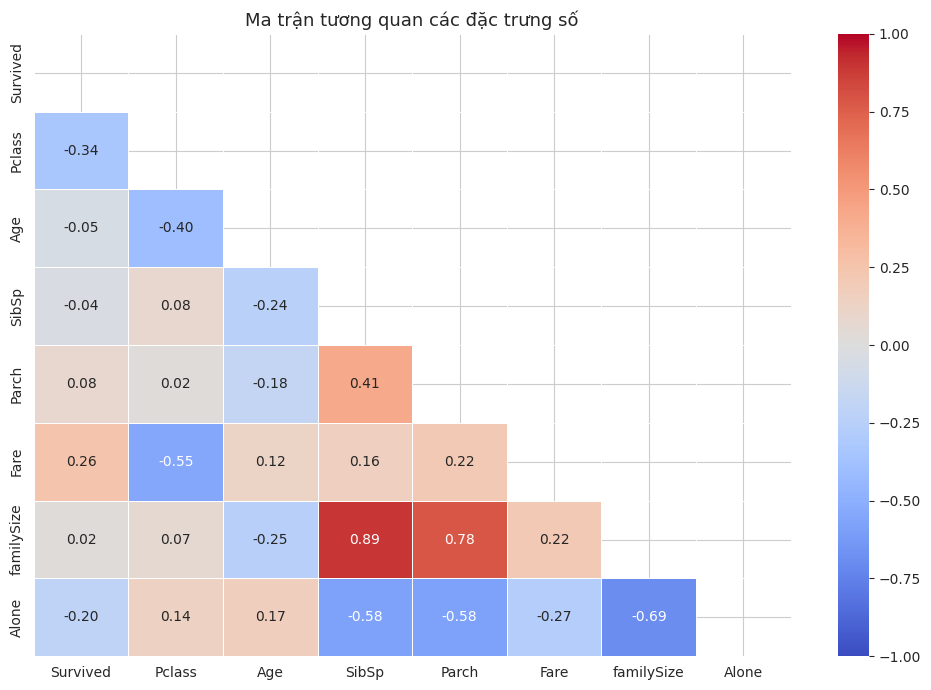

In [ ]:
# Chọn các cột số để xem tương quan
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'familySize', 'Alone']

plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Ma trận tương quan các đặc trưng số', fontsize=13)
plt.tight_layout()
plt.show()

NHẬN XÉT MA TRẬN TƯƠNG QUAN:
  - Pclass  vs Survived: tương quan âm (-0.34) → hạng càng thấp, càng ít sống sót
  - Fare    vs Survived: tương quan dương (+0.26) → vé đắt → sống sót nhiều hơn
  - Alone   vs Survived: tương quan âm (-0.20) → đi một mình → ít sống sót hơn
  - Age     vs Survived: tương quan yếu (-0.06)